# AML Alert Prioritization — Team 10x Engineers (EC6D41A5)
WIUT Hackathon 2026 · Fintech / AI in Finance

Predict the probability that each AML alert is escalated (metric: ROC-AUC).

**Reproduce:** put the organisers' files in `data/` (`train_signals.csv`, `test_signals.csv`, `train_transactions.parquet`, `test_transactions.parquet`, `sample_submission.csv`), install `requirements.txt`, then *Run All*. Runtime ≈ 25 min on a 12-core laptop.

Pipeline:
1. Quick EDA (full EDA with interactive charts: see the team website)
2. Feature engineering (`features.py`, `features3.py`, `features4.py`)
3. Feature selection by LightGBM gain (`select_features.py`)
4. Final ensemble LightGBM + CatBoost + logistic regression, 5-fold × 5 seeds (`train.py`)
5. Submission validation

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
pd.set_option('display.width', 140)
s = pd.read_csv('data/train_signals.csv', parse_dates=['signal_sanasi'])
st = pd.read_csv('data/test_signals.csv', parse_dates=['signal_sanasi'])
t = pd.read_parquet('data/train_transactions.parquet')
print(s.shape, st.shape, t.shape)
print('escalation rate:', s.eskalatsiya.mean().round(4))
print('train dates', s.signal_sanasi.min().date(), '→', s.signal_sanasi.max().date(), '| test dates', st.signal_sanasi.min().date(), '→', st.signal_sanasi.max().date())
t.head()

(14000, 3) (6000, 2) (6987663, 5)
escalation rate: 0.1718
train dates 2025-01-01 → 2026-12-31 | test dates 2025-01-01 → 2026-12-31


,signal_id,tranzaksiya_vaqti,kirim_chiqim,tranzaksiya_turi,miqdor_indeksi
0,SG_016527,2024-07-06 08:47:18,chiqim,bank_otkazmasi,0.236245
1,SG_016527,2024-07-07 02:13:02,chiqim,bank_otkazmasi,1.130377
2,SG_016527,2024-07-08 11:15:12,kirim,karta,0.466360
3,SG_016527,2024-07-08 15:58:21,kirim,karta,-0.591761
4,SG_016527,2024-07-09 02:33:17,kirim,bank_otkazmasi,-1.108945


## 1. EDA highlights

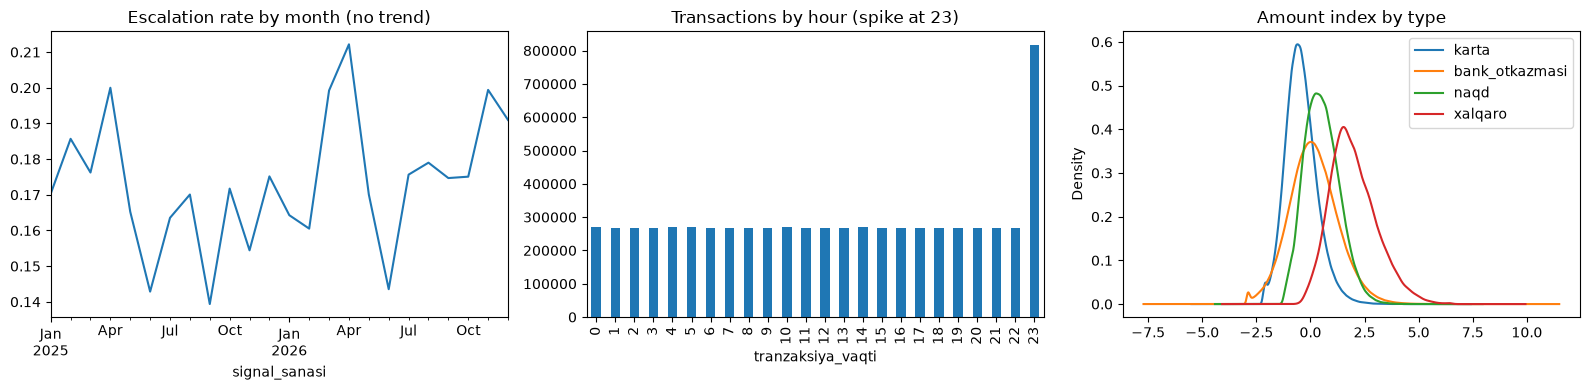

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
s.groupby(s.signal_sanasi.dt.to_period('M')).eskalatsiya.mean().plot(ax=ax[0], title='Escalation rate by month (no trend)')
t.tranzaksiya_vaqti.dt.hour.value_counts().sort_index().plot.bar(ax=ax[1], title='Transactions by hour (spike at 23)')
for ty in ['karta', 'bank_otkazmasi', 'naqd', 'xalqaro']:
    t.miqdor_indeksi[t.tranzaksiya_turi == ty].plot.kde(ax=ax[2], label=ty)
ax[2].legend(); ax[2].set_title('Amount index by type'); plt.tight_layout()

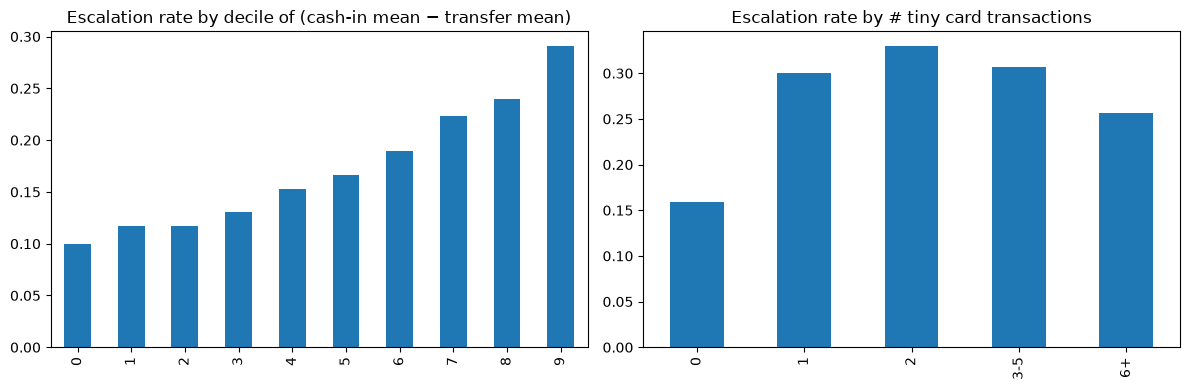

In [3]:
# The key EDA finding: escalation depends on relative size (cash deposits vs bank transfers), not absolute size
g = t.groupby(['signal_id', 'kirim_chiqim', 'tranzaksiya_turi']).miqdor_indeksi.mean().unstack([1, 2])
y = s.set_index('signal_id').eskalatsiya
diff = (g[('kirim', 'naqd')] - t[t.tranzaksiya_turi == 'bank_otkazmasi'].groupby('signal_id').miqdor_indeksi.mean()).dropna()
tiny = t[(t.tranzaksiya_turi == 'karta') & (t.miqdor_indeksi < -2.2)].groupby('signal_id').size().reindex(y.index).fillna(0)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
y.loc[diff.index].groupby(pd.qcut(diff, 10, labels=False)).mean().plot.bar(ax=ax[0], title='Escalation rate by decile of (cash-in mean − transfer mean)')
y.groupby(pd.cut(tiny, [-1, 0, 1, 2, 5, 1000], labels=['0', '1', '2', '3-5', '6+'])).mean().plot.bar(ax=ax[1], title='Escalation rate by # tiny card transactions')
plt.tight_layout(); del t

## 2. Feature engineering
- `features.py`: counts/amount stats per direction, type, direction×type, time windows, bursts, gaps
- `features3.py`: relative features — each group vs the customer's own overall level, pairwise group differences
- `features4.py`: amount histograms per type × burst/normal, tiny-card and floor counts

(`features2.py` — recent-vs-baseline and pass-through features — was tested, scored lower and is not used.)

In [4]:
import features, features3, features4
for split in ['train', 'test']:
    X, yy = features.build(split)
    if yy is not None: X['eskalatsiya'] = yy
    X.to_parquet(f'data/feat_{split}.parquet')
    features3.build(split).to_parquet(f'data/feat3_{split}.parquet')
    features4.build(split).to_parquet(f'data/feat4_{split}.parquet')
    print(split, 'done')

train done


test done


## 3. Feature selection
Rank all 857 features by LightGBM gain over 5-fold × 3 seeds; the final model keeps the top 100 (0.663 vs 0.654 with all features).

In [5]:
%run select_features.py

all features: 857, OOF AUC 0.6537


## 4. Final model
Stratified 5-fold × 5 seeds. LightGBM (fixed 380 trees, found by early stopping in CV), CatBoost, and quantile-transformed logistic regression; probability blend 0.8 / 0.1 / 0.1. Test predictions average the 25 fold models.

In [6]:
%run train.py

seed 0 {'lgbm': 0.6611, 'cat': 0.6496, 'lr': 0.6499}


seed 1 {'lgbm': 0.6636, 'cat': 0.6539, 'lr': 0.6529}


seed 2 {'lgbm': 0.6639, 'cat': 0.6548, 'lr': 0.6537}


seed 3 {'lgbm': 0.6635, 'cat': 0.6546, 'lr': 0.654}


seed 4 {'lgbm': 0.6633, 'cat': 0.6543, 'lr': 0.6536}


OOF AUC per model: {'lgbm': 0.6632742803506064, 'cat': 0.6543220740892152, 'lr': 0.6536327132187416}
blend OOF AUC 0.6631 weights {'lgbm': 0.8, 'cat': 0.1, 'lr': 0.1}
wrote 6000 rows


## 5. Validate submission

In [7]:
sub = pd.read_csv('submission/team_EC6D41A5.csv')
assert list(sub.columns) == ['signal_id', 'ehtimollik']
assert len(sub) == len(st) and set(sub.signal_id) == set(st.signal_id) and sub.signal_id.is_unique
assert sub.ehtimollik.notna().all() and sub.ehtimollik.between(0, 1).all()
print('submission OK', sub.shape); print(json.load(open('submission/model_report.json'))['oof_auc'])
sub.describe()

submission OK (6000, 2)
{'lgbm': 0.6632742803506064, 'cat': 0.6543220740892152, 'lr': 0.6536327132187416}


,ehtimollik
count,6000.000000
mean,0.171292
std,0.080306
min,0.061961
25%,0.106556
50%,0.141058
75%,0.230264
max,0.443643
